<a href="https://colab.research.google.com/github/ayushi777lodhi-stack/GraphicalNeuralNetworks/blob/main/TGN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
!pip install skyfield
!pip install networkx
!pip install matplotlib
!pip install torch-geometric
!pip install scipy

In [106]:
import networkx as nx
import numpy as np
from scipy.spatial import KDTree
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [107]:
from skyfield.api import load,EarthSatellite
import pandas as pd
from sklearn.metrics import (roc_auc_score,average_precision_score,precision_score,recall_score,f1_score)

In [108]:
import torch
from torch_geometric.data import Data
import math
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import Dataset, DataLoader

In [109]:
satellites=load.tle_file("starlink.tle")
print(f"loaded {len(satellites)} satellites")

loaded 10778 satellites


In [110]:
ts = load.timescale()

t = ts.now()

In [111]:
t = ts.utc(2026, 7, 24, 12, 0, 0)

In [112]:
dataset=[]
for sat in satellites:
    g=sat.at(t)
    position=g.position.km
    velocity=g.velocity.km_per_s

    dataset.append([
        sat.name,
        t.utc_iso(),
        position[0],
        position[1],
        position[2],
        velocity[0],
        velocity[1],
        velocity[2]
    ])

df=pd.DataFrame(
    dataset,
    columns=[
        "name",
        "time",
        "x",
        "y",
        "z",
        "vx",
        "vy",
        "vz"
    ]
)

print(df)

                 name                  time            x            y  \
0       STARLINK-1008  2026-07-24T12:00:00Z -1884.399223  4672.464570   
1       STARLINK-1012  2026-07-24T12:00:00Z -4494.996031 -2653.001603   
2       STARLINK-1017  2026-07-24T12:00:00Z  4060.186824  -768.505987   
3       STARLINK-1020  2026-07-24T12:00:00Z  3399.490070 -3865.453630   
4       STARLINK-1036  2026-07-24T12:00:00Z -5121.915540 -2613.676052   
...               ...                   ...          ...          ...   
10773  STARLINK-38090  2026-07-24T12:00:00Z  3168.381662  2099.338275   
10774  STARLINK-38084  2026-07-24T12:00:00Z  4532.808762  3871.356707   
10775  STARLINK-38085  2026-07-24T12:00:00Z  2589.853277  1444.425816   
10776  STARLINK-38091  2026-07-24T12:00:00Z  2279.168591  1105.131689   
10777  STARLINK-38086  2026-07-24T12:00:00Z  1954.491950   758.189645   

                 z        vx        vy        vz  
0     -4549.041524 -4.634278 -5.110161 -3.325540  
1     -4331.176120  0

In [113]:
snapshots=[]
times=[
    ts.utc(2026,7,24,12,0),
    ts.utc(2026,7,24,12,5),
    ts.utc(2026,7,24,12,10),
    ts.utc(2026,7,24,12,15),
]
for t in times:
    rows=[]
    for sat in satellites:
        g=sat.at(t)
        position=g.position.km
        velocity=g.velocity.km_per_s

        rows.append([
            sat.name,
            position[0],
            position[1],
            position[2],
            velocity[0],
            velocity[1],
            velocity[2]
        ])

    df=pd.DataFrame(
        rows,
        columns=[
            "name",
            "x",
            "y",
            "z",
            "vx",
            "vy",
            "vz"
        ]
    )

    snapshots.append(df)



In [114]:
snapshots[0].head()

,name,x,y,z,vx,vy,vz
0,STARLINK-1008,-1884.399223,4672.464570,-4549.041524,-4.634278,-5.110161,-3.325540
1,STARLINK-1012,-4494.996031,-2653.001603,-4331.176120,0.421612,-6.709482,3.680630
2,STARLINK-1017,4060.186824,-768.505987,5440.728694,1.822267,7.412165,-0.311817
3,STARLINK-1020,3399.490070,-3865.453630,4378.437185,2.540890,6.299899,3.587014
4,STARLINK-1036,-5121.915540,-2613.676052,-3468.754856,-0.046957,-6.112923,4.687137


In [115]:
snapshots[1].head()

,name,x,y,z,vx,vy,vz
0,STARLINK-1008,-3141.492831,2903.635914,-5269.129512,-3.666401,-6.569210,-1.429264
1,STARLINK-1012,-4115.170671,-4476.559379,-3000.946362,2.086893,-5.330415,5.102776
2,STARLINK-1017,4371.145183,1456.499850,5045.828754,0.231311,7.282327,-2.296225
3,STARLINK-1020,3951.829308,-1789.765254,5181.567232,1.106012,7.403809,1.715587
4,STARLINK-1036,-4835.267452,-4258.211937,-1886.237174,1.939795,-4.741641,5.758684


In [116]:
def build_graph(df, communication_radius=1000):

    G=nx.Graph()
    for _,row in df.iterrows():
        G.add_node(
            row["name"],
            pos=(row["x"], row["y"], row["z"]),
            velocity=(row["vx"], row["vy"], row["vz"])
        )

    positions=df[["x","y","z"]].values
    tree=KDTree(positions)
    for i,point in enumerate(positions):
        neighbors=tree.query_ball_point(point, communication_radius)

        for j in neighbors:
            if i>=j:
                continue
            distance=np.linalg.norm(positions[i] - positions[j])

            G.add_edge(
                df.iloc[i]["name"],
                df.iloc[j]["name"],
                distance=distance
            )

    return G

In [117]:
def get_snapshot(satellites,t):
    rows=[]
    for sat in satellites:
        geocentric=sat.at(t)
        position=geocentric.position.km
        velocity=geocentric.velocity.km_per_s

        rows.append({
            "time":t,
            "name":sat.name,
            "x":position[0],
            "y":position[1],
            "z":position[2],
            "vx":velocity[0],
            "vy":velocity[1],
            "vz":velocity[2]
        })

    return pd.DataFrame(rows)

In [118]:
start=datetime(2026,7,24,0,0)
times=[]

for i in range(100):
    current=start+timedelta(minutes=5*i)
    times.append(ts.utc(current.year,
            current.month,
            current.day,
            current.hour,
            current.minute,
            current.second))

In [119]:
print(times)

[<Time tt=2461245.500800741>, <Time tt=2461245.504272963>, <Time tt=2461245.5077451854>, <Time tt=2461245.5112174074>, <Time tt=2461245.5146896294>, <Time tt=2461245.518161852>, <Time tt=2461245.521634074>, <Time tt=2461245.5251062964>, <Time tt=2461245.5285785184>, <Time tt=2461245.532050741>, <Time tt=2461245.535522963>, <Time tt=2461245.5389951854>, <Time tt=2461245.5424674074>, <Time tt=2461245.5459396294>, <Time tt=2461245.549411852>, <Time tt=2461245.552884074>, <Time tt=2461245.5563562964>, <Time tt=2461245.5598285184>, <Time tt=2461245.563300741>, <Time tt=2461245.566772963>, <Time tt=2461245.5702451854>, <Time tt=2461245.5737174074>, <Time tt=2461245.5771896294>, <Time tt=2461245.580661852>, <Time tt=2461245.584134074>, <Time tt=2461245.5876062964>, <Time tt=2461245.5910785184>, <Time tt=2461245.594550741>, <Time tt=2461245.598022963>, <Time tt=2461245.6014951854>, <Time tt=2461245.6049674074>, <Time tt=2461245.6084396294>, <Time tt=2461245.611911852>, <Time tt=2461245.6153840

In [120]:
graphs=[]
for t in times:
    df=get_snapshot(satellites[:400], t)
    G=build_graph(df)
    graphs.append(G)

In [121]:
print(df.head())

                          time           name            x            y  \
0  <Time tt=2461245.844550741>  STARLINK-1008  3477.500962 -2252.183643   
1  <Time tt=2461245.844550741>  STARLINK-1012  3844.932526  4978.014015   
2  <Time tt=2461245.844550741>  STARLINK-1017 -4205.187326 -3346.977635   
3  <Time tt=2461245.844550741>  STARLINK-1020 -4006.621038  1528.927375   
4  <Time tt=2461245.844550741>  STARLINK-1036  4970.034587  3710.480373   

             z        vx        vy        vz  
0  5360.499071  3.207344  6.918781  0.829676  
1  2537.140814 -2.595398  4.774686 -5.408848  
2 -4237.875815  1.285091 -6.466903  3.836386  
3 -5233.054524 -0.856897 -7.469651 -1.521280  
4  2563.871296 -1.211224  5.370986 -5.396243  


In [122]:
for G in graphs:
    print(G)

Graph with 400 nodes and 608 edges
Graph with 400 nodes and 602 edges
Graph with 400 nodes and 581 edges
Graph with 400 nodes and 613 edges
Graph with 400 nodes and 552 edges
Graph with 400 nodes and 571 edges
Graph with 400 nodes and 604 edges
Graph with 400 nodes and 576 edges
Graph with 400 nodes and 581 edges
Graph with 400 nodes and 605 edges
Graph with 400 nodes and 580 edges
Graph with 400 nodes and 618 edges
Graph with 400 nodes and 596 edges
Graph with 400 nodes and 577 edges
Graph with 400 nodes and 598 edges
Graph with 400 nodes and 630 edges
Graph with 400 nodes and 612 edges
Graph with 400 nodes and 587 edges
Graph with 400 nodes and 597 edges
Graph with 400 nodes and 605 edges
Graph with 400 nodes and 620 edges
Graph with 400 nodes and 589 edges
Graph with 400 nodes and 587 edges
Graph with 400 nodes and 588 edges
Graph with 400 nodes and 564 edges
Graph with 400 nodes and 641 edges
Graph with 400 nodes and 601 edges
Graph with 400 nodes and 583 edges
Graph with 400 nodes

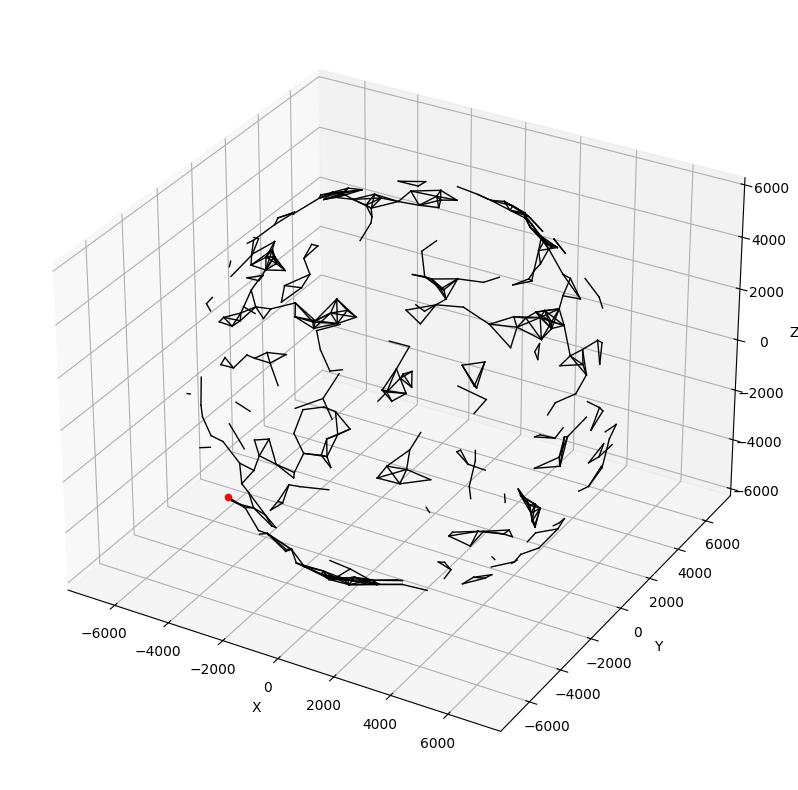

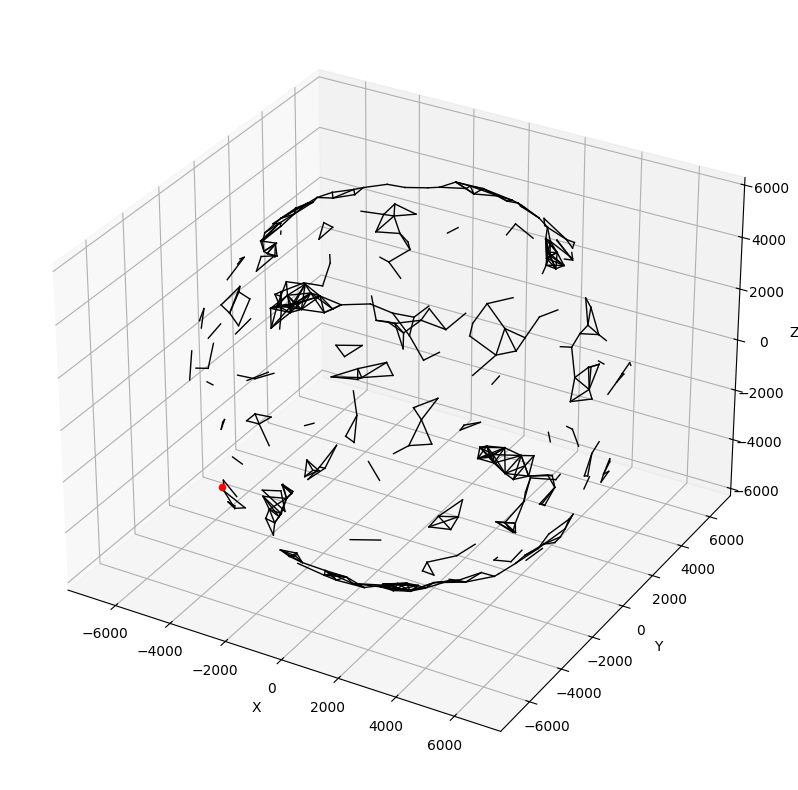

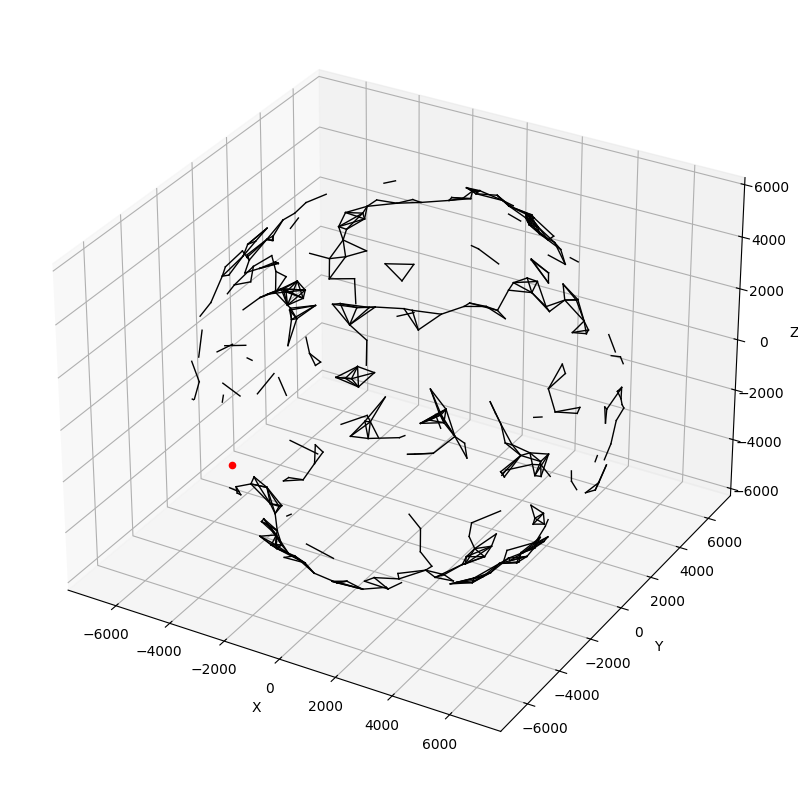

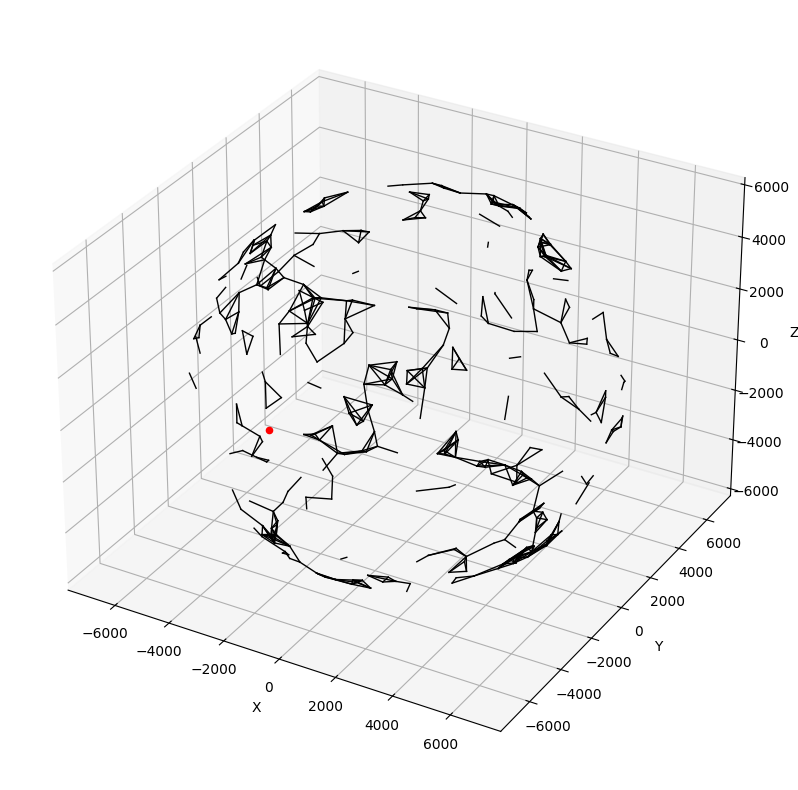

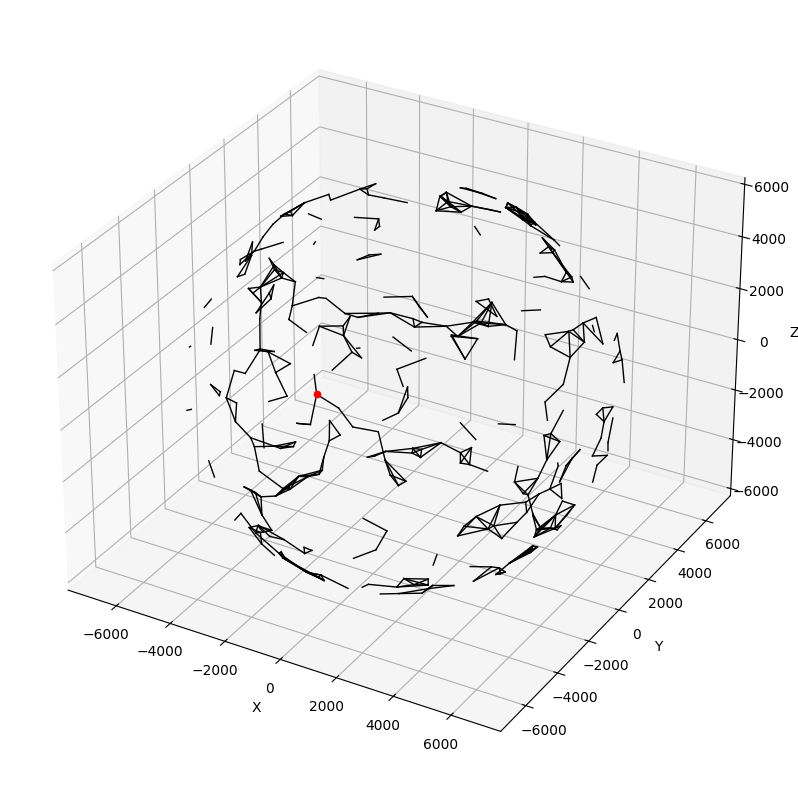

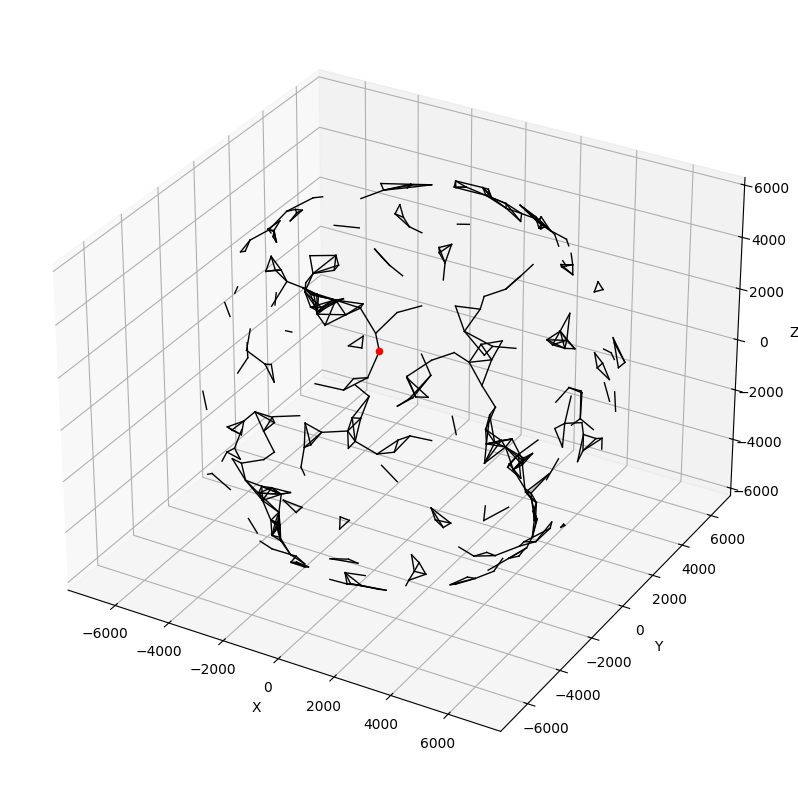

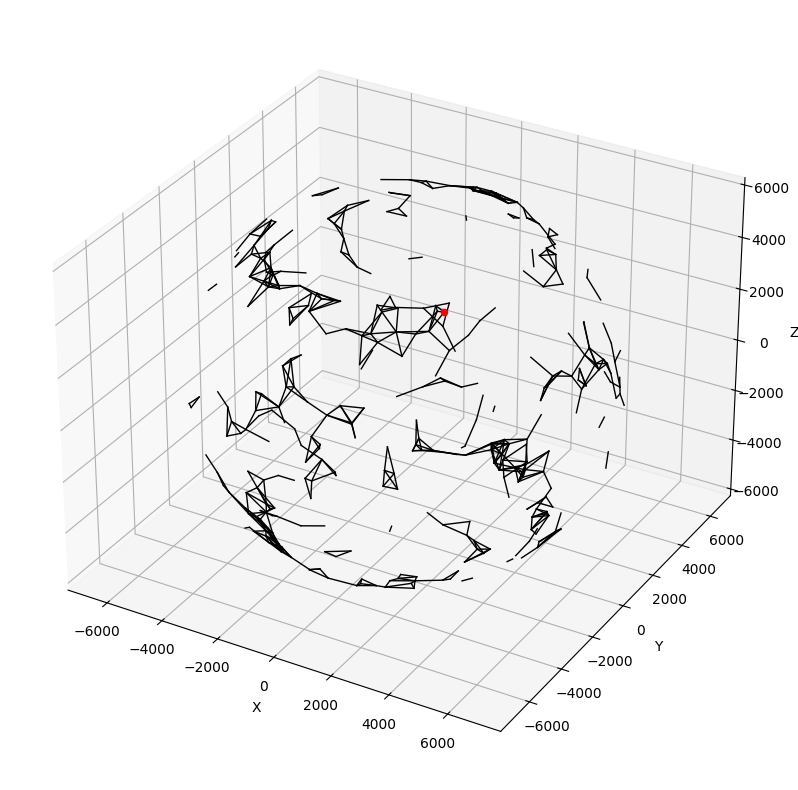

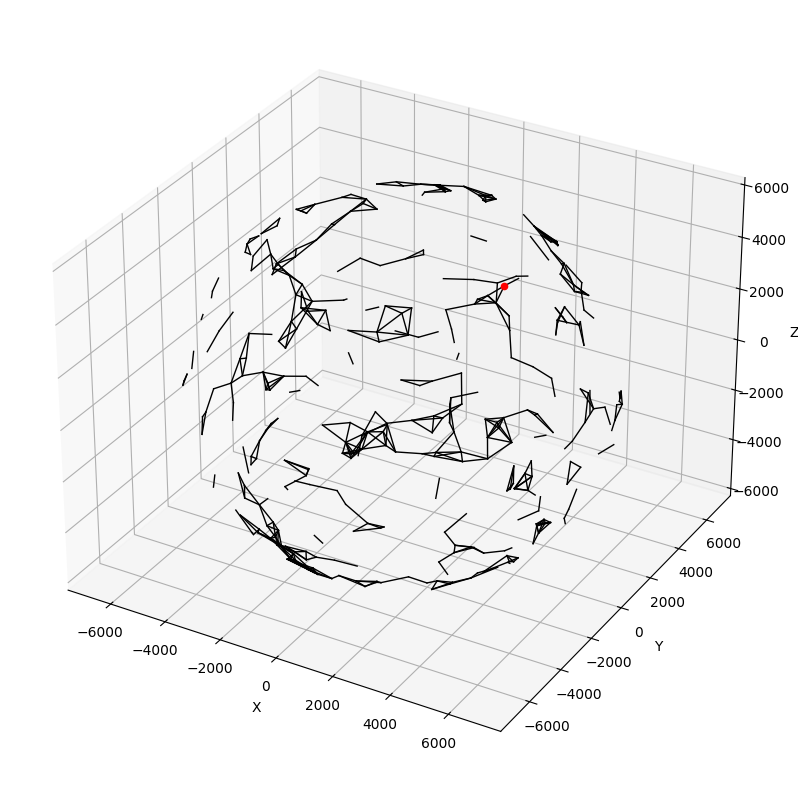

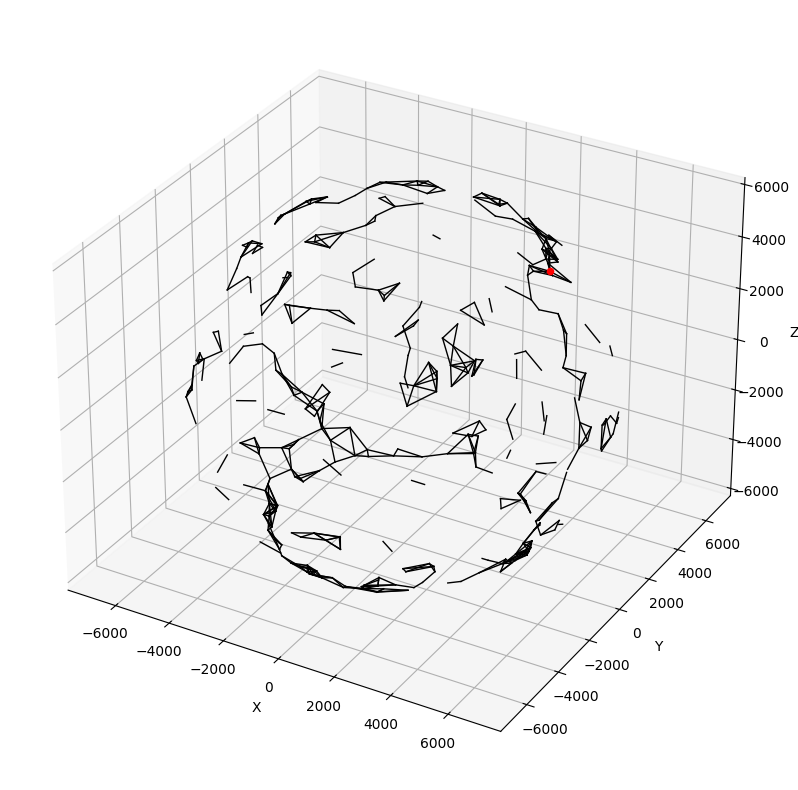

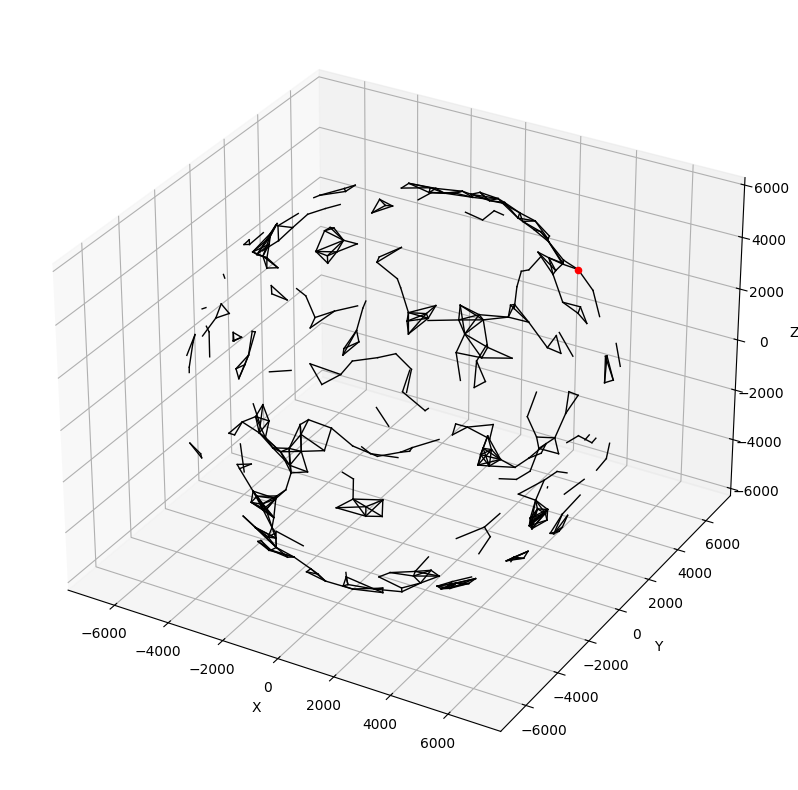

In [123]:
for G in graphs[:10]:
    fig=plt.figure(figsize=(10,10))
    ax=fig.add_subplot(111, projection="3d")

    for u,v in G.edges():
       p1=np.array(G.nodes[u]["pos"])
       p2=np.array(G.nodes[v]["pos"])

       ax.plot(
           [p1[0], p2[0]],
        [p1[1], p2[1]],
        [p1[2], p2[2]],
        color="black",
        linewidth=1
    )

    xs=[]
    ys=[]
    zs=[]

    for node in G.nodes():
        x,y,z=G.nodes[node]["pos"]

        xs.append(x)
        ys.append(y)
        zs.append(z)
        ax.scatter(xs, ys, zs, color="red", s=20)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        plt.show()

In [124]:
G.nodes

NodeView(('STARLINK-1008', 'STARLINK-1012', 'STARLINK-1017', 'STARLINK-1020', 'STARLINK-1036', 'STARLINK-1039', 'STARLINK-1042', 'STARLINK-1043', 'STARLINK-1046', 'STARLINK-1047', 'STARLINK-1048', 'STARLINK-1063', 'STARLINK-1067', 'STARLINK-1068', 'STARLINK-1114', 'STARLINK-1123', 'STARLINK-1094', 'STARLINK-1122', 'STARLINK-1080', 'STARLINK-1090', 'STARLINK-1132', 'STARLINK-1131', 'STARLINK-1134', 'STARLINK-1156', 'STARLINK-1166', 'STARLINK-1169', 'STARLINK-1171', 'STARLINK-1133', 'STARLINK-1167', 'STARLINK-1168', 'STARLINK-1172', 'STARLINK-1153', 'STARLINK-1151', 'STARLINK-1185', 'STARLINK-1183', 'STARLINK-1152', 'STARLINK-1184', 'STARLINK-1193', 'STARLINK-1143', 'STARLINK-1202', 'STARLINK-1216', 'STARLINK-1225', 'STARLINK-1230', 'STARLINK-1234', 'STARLINK-1269', 'STARLINK-1154', 'STARLINK-1199', 'STARLINK-1209', 'STARLINK-1231', 'STARLINK-1271', 'STARLINK-1191', 'STARLINK-1212', 'STARLINK-1215', 'STARLINK-1221', 'STARLINK-1222', 'STARLINK-1226', 'STARLINK-1227', 'STARLINK-1246', 'STA

In [125]:
node_to_idx={
    node:i
    for i,node in enumerate(G.nodes())
}

print(node_to_idx)

{'STARLINK-1008': 0, 'STARLINK-1012': 1, 'STARLINK-1017': 2, 'STARLINK-1020': 3, 'STARLINK-1036': 4, 'STARLINK-1039': 5, 'STARLINK-1042': 6, 'STARLINK-1043': 7, 'STARLINK-1046': 8, 'STARLINK-1047': 9, 'STARLINK-1048': 10, 'STARLINK-1063': 11, 'STARLINK-1067': 12, 'STARLINK-1068': 13, 'STARLINK-1114': 14, 'STARLINK-1123': 15, 'STARLINK-1094': 16, 'STARLINK-1122': 17, 'STARLINK-1080': 18, 'STARLINK-1090': 19, 'STARLINK-1132': 20, 'STARLINK-1131': 21, 'STARLINK-1134': 22, 'STARLINK-1156': 23, 'STARLINK-1166': 24, 'STARLINK-1169': 25, 'STARLINK-1171': 26, 'STARLINK-1133': 27, 'STARLINK-1167': 28, 'STARLINK-1168': 29, 'STARLINK-1172': 30, 'STARLINK-1153': 31, 'STARLINK-1151': 32, 'STARLINK-1185': 33, 'STARLINK-1183': 34, 'STARLINK-1152': 35, 'STARLINK-1184': 36, 'STARLINK-1193': 37, 'STARLINK-1143': 38, 'STARLINK-1202': 39, 'STARLINK-1216': 40, 'STARLINK-1225': 41, 'STARLINK-1230': 42, 'STARLINK-1234': 43, 'STARLINK-1269': 44, 'STARLINK-1154': 45, 'STARLINK-1199': 46, 'STARLINK-1209': 47, '

In [126]:
def networkx_to_pyg(G):
    node_features=[]
    for node in G.nodes():
       x,y,z=G.nodes[node]["pos"]
       vx,vy,vz=G.nodes[node]["velocity"]
       node_features.append([x,y,z,vx,vy,vz])

    x=torch.tensor(node_features, dtype=torch.float)

    edges=[]
    for u,v in G.edges():
        edges.append([node_to_idx[u],node_to_idx[v]])
        edges.append([node_to_idx[v],node_to_idx[u]])

    edge_index=torch.tensor(edges,dtype=torch.long).t().contiguous()

    edge_attr=[]
    for u,v in G.edges():
        d=G.edges[u,v]["distance"]
        edge_attr.append([d])

    edge_attr=torch.tensor(edge_attr, dtype=torch.float)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr
    )

In [127]:
for G in graphs:
  print(G)

Graph with 400 nodes and 608 edges
Graph with 400 nodes and 602 edges
Graph with 400 nodes and 581 edges
Graph with 400 nodes and 613 edges
Graph with 400 nodes and 552 edges
Graph with 400 nodes and 571 edges
Graph with 400 nodes and 604 edges
Graph with 400 nodes and 576 edges
Graph with 400 nodes and 581 edges
Graph with 400 nodes and 605 edges
Graph with 400 nodes and 580 edges
Graph with 400 nodes and 618 edges
Graph with 400 nodes and 596 edges
Graph with 400 nodes and 577 edges
Graph with 400 nodes and 598 edges
Graph with 400 nodes and 630 edges
Graph with 400 nodes and 612 edges
Graph with 400 nodes and 587 edges
Graph with 400 nodes and 597 edges
Graph with 400 nodes and 605 edges
Graph with 400 nodes and 620 edges
Graph with 400 nodes and 589 edges
Graph with 400 nodes and 587 edges
Graph with 400 nodes and 588 edges
Graph with 400 nodes and 564 edges
Graph with 400 nodes and 641 edges
Graph with 400 nodes and 601 edges
Graph with 400 nodes and 583 edges
Graph with 400 nodes

In [128]:
pyg_graphs=[]

for G in graphs:
    data=networkx_to_pyg(G)
    pyg_graphs.append(data)

In [129]:
print(pyg_graphs)

[Data(x=[400, 6], edge_index=[2, 1216], edge_attr=[608, 1]), Data(x=[400, 6], edge_index=[2, 1204], edge_attr=[602, 1]), Data(x=[400, 6], edge_index=[2, 1162], edge_attr=[581, 1]), Data(x=[400, 6], edge_index=[2, 1226], edge_attr=[613, 1]), Data(x=[400, 6], edge_index=[2, 1104], edge_attr=[552, 1]), Data(x=[400, 6], edge_index=[2, 1142], edge_attr=[571, 1]), Data(x=[400, 6], edge_index=[2, 1208], edge_attr=[604, 1]), Data(x=[400, 6], edge_index=[2, 1152], edge_attr=[576, 1]), Data(x=[400, 6], edge_index=[2, 1162], edge_attr=[581, 1]), Data(x=[400, 6], edge_index=[2, 1210], edge_attr=[605, 1]), Data(x=[400, 6], edge_index=[2, 1160], edge_attr=[580, 1]), Data(x=[400, 6], edge_index=[2, 1236], edge_attr=[618, 1]), Data(x=[400, 6], edge_index=[2, 1192], edge_attr=[596, 1]), Data(x=[400, 6], edge_index=[2, 1154], edge_attr=[577, 1]), Data(x=[400, 6], edge_index=[2, 1196], edge_attr=[598, 1]), Data(x=[400, 6], edge_index=[2, 1260], edge_attr=[630, 1]), Data(x=[400, 6], edge_index=[2, 1224], 

In [130]:
class SatelliteTemporalDataset(Dataset):
    def __init__(self,graphs,history):
        self.graphs=graphs
        self.history=history

    def __len__(self):
        return len(self.graphs)-self.history

    def __getitem__(self,idx):
        input_sequence=self.graphs[idx:idx+self.history]
        target_graph=self.graphs[idx+self.history]

        return input_sequence,target_graph

In [131]:
history=4
dataset=SatelliteTemporalDataset(
    pyg_graphs,
    history=history
)

In [132]:
print(len(dataset))

96


In [133]:
def collate_fn(batch):
    histories=[]
    targets=[]

    for history,target in batch:
        histories.append(history)
        targets.append(target)

    return histories, targets

In [134]:
loader=DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

In [135]:
for histories,targets in loader:
    print(len(histories))
    print(len(targets))
    break

2
2


In [136]:
from torch_geometric.utils import softmax
from torch_geometric.utils import scatter


class StructuralAttention(nn.Module):
    def __init__(self,in_dim,hidden_dim,num_heads=8,dropout=0.1):
        super().__init__()
        assert hidden_dim%num_heads==0

        self.hidden_dim=hidden_dim
        self.num_heads=num_heads
        self.head_dim=hidden_dim//num_heads
        self.W=nn.Linear(in_dim,hidden_dim,bias=False)
        self.attn=nn.Parameter(torch.empty(num_heads,2*self.head_dim))
        nn.init.uniform_(self.attn,-0.1,0.1)
        self.dropout=nn.Dropout(dropout)

    def forward(self,x,edge_index):
        src,dst=edge_index
        N=x.size(0)
        Wh=self.W(x)
        Wh=Wh.view(N,self.num_heads,self.head_dim)
        Wh_src=Wh[src]
        Wh_dst=Wh[dst]
        edge_features=torch.cat([Wh_src, Wh_dst],dim=-1)
        e=(edge_features*self.attn.unsqueeze(0)).sum(dim=-1)
        e=F.leaky_relu(e,0.2)
        alpha=softmax(e,dst)
        alpha=self.dropout(alpha)
        out=scatter(alpha.unsqueeze(-1)*Wh_src,dst,dim=0,dim_size=N,reduce="sum")
        out=out.reshape(N,self.hidden_dim)

        return F.elu(out)

In [137]:
class StructuralBlock(nn.Module):
    def __init__(self,in_dim,hidden_dim,num_layers):
        super().__init__()

        self.layers=nn.ModuleList([
    StructuralAttention(
        in_dim if i==0 else hidden_dim,
        hidden_dim,
        num_heads=8)
    for i in range(num_layers)
    ])

    def forward(self, x, edge_index):
        for layer in self.layers:
            x=layer(x, edge_index)

        return x

In [138]:
structural=StructuralBlock(
    in_dim=6,
    hidden_dim=64,
    num_layers=2
)

In [139]:
class MultiHeadTemporalAttention(nn.Module):
    def __init__(self,hidden_dim,num_heads=8,dropout=0.1):
        super().__init__()
        assert hidden_dim%num_heads==0

        self.hidden_dim=hidden_dim
        self.num_heads=num_heads
        self.head_dim=hidden_dim//num_heads

        self.query=nn.Linear(hidden_dim,hidden_dim,bias=False)
        self.key=nn.Linear(hidden_dim,hidden_dim,bias=False)
        self.value=nn.Linear(hidden_dim,hidden_dim,bias=False)

        self.out_proj=nn.Linear(hidden_dim,hidden_dim)
        self.dropout=nn.Dropout(dropout)

    def forward(self,x):
        x=x.permute(1,0,2).contiguous()
        N,T,_ =x.shape
        Q=self.query(x)
        K=self.key(x)
        V=self.value(x)


        Q=Q.reshape(N,T,self.num_heads,self.head_dim)
        K=K.reshape(N,T,self.num_heads,self.head_dim)
        V=V.reshape(N,T,self.num_heads,self.head_dim)

        Q=Q.transpose(1,2)
        K=K.transpose(1,2)
        V=V.transpose(1,2)
        scores=torch.matmul(Q,K.transpose(-2,-1))
        scores=scores/math.sqrt(self.head_dim)

        mask=torch.triu(torch.ones(T,T,device=x.device),diagonal=1).bool()
        scores=scores.masked_fill(mask,float("-inf"))
        attention=F.softmax(scores,dim=-1)
        attention=self.dropout(attention)
        out=torch.matmul(attention,V)
        out=out.transpose(1,2).contiguous()
        out=out.view(N,T,self.hidden_dim)
        out=self.out_proj(out)
        out=out.permute(1,0,2)

        return out

In [140]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim, dropout=0.1):
        super().__init__()

        self.hidden_dim=hidden_dim
        self.Wq=nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.Wk=nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.Wv=nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.dropout=nn.Dropout(dropout)

    def forward(self, x):
        x=x.permute(1,0,2)
        Q=self.Wq(x)
        K=self.Wk(x)
        V=self.Wv(x)
        scores = torch.matmul(Q,K.transpose(-2, -1))
        scores=scores/math.sqrt(self.hidden_dim)
        T=scores.size(-1)
        mask=torch.triu(torch.ones(T,T,device=x.device),diagonal=1).bool()
        scores=scores.masked_fill(mask,float("-inf"))
        attention=F.softmax(scores,dim=-1)
        attention=self.dropout(attention)
        out=torch.matmul(attention,V)
        out=out.permute(1,0,2)

        return out

In [141]:
class PositionEmbedding(nn.Module):
    def __init__(self,num_snapshots,hidden_dim):
        super().__init__()
        self.position=nn.Parameter(torch.randn(num_snapshots, hidden_dim))

    def forward(self,x):
        return x+self.position[:, None, :]

In [142]:
class FeedForward(nn.Module):
    def __init__(self,hidden_dim,dropout=0.1):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(hidden_dim,hidden_dim*4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim*4,hidden_dim)
         )

    def forward(self,x):
        return self.net(x)

In [143]:
class TemporalBlock(nn.Module):
    def __init__(self,hidden_dim,num_layers,num_snapshots):
        super().__init__()
        self.position_embedding=nn.Parameter(torch.randn(num_snapshots, hidden_dim))
        self.attention=nn.ModuleList([
            MultiHeadTemporalAttention(
            hidden_dim,
            num_heads=8,
            dropout=0.1)
            for _ in range(num_layers)
        ])

        self.feed_forward=nn.ModuleList([
            FeedForward(hidden_dim)
            for _ in range(num_layers)
        ])

        self.norm1=nn.ModuleList([
            nn.LayerNorm(hidden_dim)
            for _ in range(num_layers)
        ])

        self.norm2=nn.ModuleList([
            nn.LayerNorm(hidden_dim)
            for _ in range(num_layers)
        ])

    def forward(self,H):
      H=H+self.position_embedding[:, None, :]
      print(self.position_embedding.shape)
      for attn, ff, norm1, norm2 in zip(self.attention,self.feed_forward,self.norm1,self.norm2):
        H=norm1(H+attn(H))
        H=norm2(H+ff(H))

      return H

In [144]:
class DySAT(nn.Module):
    def __init__(self,input_dim,hidden_dim,structural_layers,temporal_layers,num_snapshots):
        super().__init__()
        self.structural=StructuralBlock(
            in_dim=input_dim,
            hidden_dim=hidden_dim,
            num_layers=structural_layers
        )

        self.temporal=TemporalBlock(
            hidden_dim=hidden_dim,
            num_layers=temporal_layers,
            num_snapshots=num_snapshots
        )

    def forward(self, graphs):
        structural_embeddings=[]
        for graph in graphs:
            h=self.structural(graph.x,graph.edge_index)
            structural_embeddings.append(h)

        H=torch.stack(structural_embeddings,dim=0)
        H=self.temporal(H)

        return H

In [145]:
print(graphs[0])

Graph with 400 nodes and 608 edges


In [146]:
print(pyg_graphs)

[Data(x=[400, 6], edge_index=[2, 1216], edge_attr=[608, 1]), Data(x=[400, 6], edge_index=[2, 1204], edge_attr=[602, 1]), Data(x=[400, 6], edge_index=[2, 1162], edge_attr=[581, 1]), Data(x=[400, 6], edge_index=[2, 1226], edge_attr=[613, 1]), Data(x=[400, 6], edge_index=[2, 1104], edge_attr=[552, 1]), Data(x=[400, 6], edge_index=[2, 1142], edge_attr=[571, 1]), Data(x=[400, 6], edge_index=[2, 1208], edge_attr=[604, 1]), Data(x=[400, 6], edge_index=[2, 1152], edge_attr=[576, 1]), Data(x=[400, 6], edge_index=[2, 1162], edge_attr=[581, 1]), Data(x=[400, 6], edge_index=[2, 1210], edge_attr=[605, 1]), Data(x=[400, 6], edge_index=[2, 1160], edge_attr=[580, 1]), Data(x=[400, 6], edge_index=[2, 1236], edge_attr=[618, 1]), Data(x=[400, 6], edge_index=[2, 1192], edge_attr=[596, 1]), Data(x=[400, 6], edge_index=[2, 1154], edge_attr=[577, 1]), Data(x=[400, 6], edge_index=[2, 1196], edge_attr=[598, 1]), Data(x=[400, 6], edge_index=[2, 1260], edge_attr=[630, 1]), Data(x=[400, 6], edge_index=[2, 1224], 

In [147]:
print(len(pyg_graphs))

100


In [148]:
history=4
device="cuda" if torch.cuda.is_available() else "cpu"
model=DySAT(
    input_dim=6,
    hidden_dim=64,
    structural_layers=2,
    temporal_layers=2,
    num_snapshots=history)
model=model.to(device)
history_graphs=[g.to(device) for g in pyg_graphs[:4]]
embeddings=model(history_graphs)


torch.Size([4, 64])


In [149]:
class LinkPredictor(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.predictor=nn.Sequential(
            nn.Linear(hidden_dim*2,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,1))

    def forward(self, embeddings,edge_index):
        src,dst=edge_index
        edge_embeddings=torch.cat([embeddings[src],embeddings[dst]],dim=1)
        logits=self.predictor(edge_embeddings)

        return logits.squeeze(-1)

In [150]:
split=int(0.8*len(pyg_graphs))
train_graphs=pyg_graphs[:split]
test_graphs=pyg_graphs[split:]

In [151]:
len(pyg_graphs)

100

In [152]:
print(train_graphs)
print(pyg_graphs)
print(test_graphs)

[Data(x=[400, 6], edge_index=[2, 1216], edge_attr=[608, 1]), Data(x=[400, 6], edge_index=[2, 1204], edge_attr=[602, 1]), Data(x=[400, 6], edge_index=[2, 1162], edge_attr=[581, 1]), Data(x=[400, 6], edge_index=[2, 1226], edge_attr=[613, 1]), Data(x=[400, 6], edge_index=[2, 1104], edge_attr=[552, 1]), Data(x=[400, 6], edge_index=[2, 1142], edge_attr=[571, 1]), Data(x=[400, 6], edge_index=[2, 1208], edge_attr=[604, 1]), Data(x=[400, 6], edge_index=[2, 1152], edge_attr=[576, 1]), Data(x=[400, 6], edge_index=[2, 1162], edge_attr=[581, 1]), Data(x=[400, 6], edge_index=[2, 1210], edge_attr=[605, 1]), Data(x=[400, 6], edge_index=[2, 1160], edge_attr=[580, 1]), Data(x=[400, 6], edge_index=[2, 1236], edge_attr=[618, 1]), Data(x=[400, 6], edge_index=[2, 1192], edge_attr=[596, 1]), Data(x=[400, 6], edge_index=[2, 1154], edge_attr=[577, 1]), Data(x=[400, 6], edge_index=[2, 1196], edge_attr=[598, 1]), Data(x=[400, 6], edge_index=[2, 1260], edge_attr=[630, 1]), Data(x=[400, 6], edge_index=[2, 1224], 

In [153]:
HISTORY=4
train_dataset=SatelliteTemporalDataset(
    train_graphs,
    history=HISTORY
)

test_dataset=SatelliteTemporalDataset(
    test_graphs,
    history=HISTORY
)

In [154]:
def temporal_collate(batch):
    histories=[item[0] for item in batch]
    targets=[item[1] for item in batch]

    return histories,targets

In [155]:
train_loader=DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=temporal_collate
)

test_loader=DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=temporal_collate
)

In [156]:
predictor=LinkPredictor(hidden_dim=64)

In [157]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)
predictor=predictor.to(device)
optimizer=torch.optim.Adam(list(model.parameters())+list(predictor.parameters()),lr=1e-3)
criterion=nn.BCEWithLogitsLoss()

In [158]:
from torch_geometric.utils import negative_sampling
loss_history=[]
epochs=50

for epoch in range(epochs):

    model.train()
    predictor.train()

    total_loss=0
    for histories,targets in train_loader:
        batch_loss=0
        optimizer.zero_grad()

        for history,target_graph in zip(histories, targets):
            history=[g.to(device) for g in history]
            target_graph=target_graph.to(device)
            H=model(history)
            embeddings=H[-1]

            positive_edges=target_graph.edge_index
            negative_edges=negative_sampling(
                edge_index=positive_edges,
                num_nodes=target_graph.num_nodes,
                num_neg_samples=positive_edges.size(1),
                method="sparse"
            ).to(device)
            positive_edges=positive_edges.to(device)
            positive_logits=predictor(embeddings,positive_edges)
            negative_logits=predictor(embeddings,negative_edges)
            logits=torch.cat([positive_logits,negative_logits])
            labels=torch.cat([torch.ones_like(positive_logits),torch.zeros_like(negative_logits)])

            loss=criterion(logits,labels)
            batch_loss+=loss

        batch_loss.backward()
        optimizer.step()
        total_loss+=batch_loss.item()

    avg_loss=total_loss/len(train_loader)
    loss_history.append(avg_loss)
    print(
        f"Epoch {epoch+1:03d} loss={avg_loss:.4f}"
    )

torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])


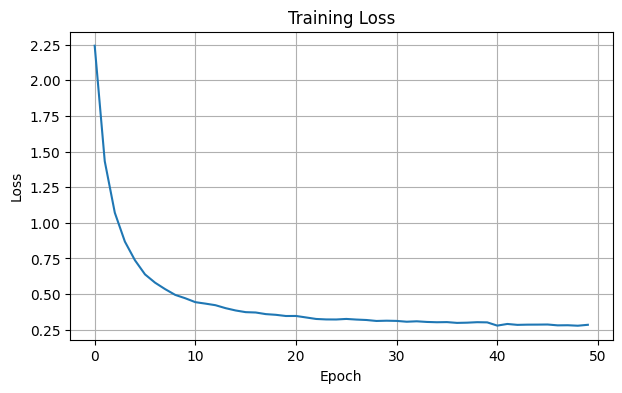

In [159]:
plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [160]:
torch.save({
    "dysat":model.state_dict(),
     "predictor":predictor.state_dict()}
    ,"dysat_link_prediction.pth",)

torch.Size([4, 64])
Real edges:592
Predicted edges:1184
TP:531
FP:653
FN:61
Probability range:0.0000 - 0.9999
Mean probability:0.0430


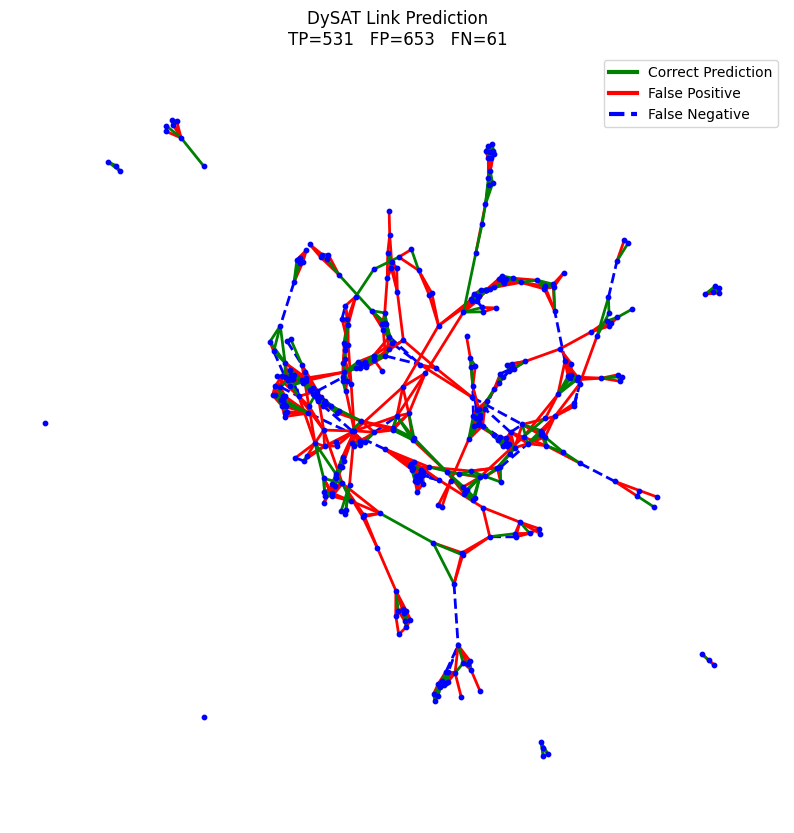

In [161]:
import itertools
from matplotlib.lines import Line2D
model.eval()
predictor.eval()

history,target_graph=test_dataset[0]
history=[g.to(device) for g in history]
target_graph=target_graph.to(device)

with torch.no_grad():
    H=model(history)

embeddings=H[-1]
num_nodes=target_graph.num_nodes

all_edges=torch.tensor(list(itertools.combinations(range(num_nodes),2)),dtype=torch.long).t().to(device)

with torch.no_grad():
    logits=predictor(embeddings,all_edges)

prob=torch.sigmoid(logits)
real_edges=target_graph.edge_index
K=real_edges.size(1)
topk=torch.topk(prob,K)
pred_edges=all_edges[:,topk.indices]
real=set(tuple(sorted(edge)) for edge in real_edges.t().cpu().tolist())
pred=set(tuple(sorted(edge)) for edge in pred_edges.t().cpu().tolist())

tp=real&pred
fp=pred-real
fn=real-pred

print(f"Real edges:{len(real)}")
print(f"Predicted edges:{len(pred)}")
print(f"TP:{len(tp)}")
print(f"FP:{len(fp)}")
print(f"FN:{len(fn)}")
print(f"Probability range:{prob.min():.4f} - {prob.max():.4f}")
print(f"Mean probability:{prob.mean():.4f}")


G=nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(real)
G.add_edges_from(pred)
pos=nx.spring_layout(G,seed=42)
plt.figure(figsize=(10,10))

nx.draw_networkx_nodes(G,pos,node_size=10,node_color="blue")
nx.draw_networkx_edges(G,pos,edgelist=list(fn),edge_color="blue",style="dashed",width=2)
nx.draw_networkx_edges(G,pos,edgelist=list(fp),edge_color="red",width=2)
nx.draw_networkx_edges(G,pos,edgelist=list(tp),edge_color="green",width=2)

legend=[
    Line2D(
        [0],
        [0],
        color="green",
        lw=3,
        label="Correct Prediction"
    ),

    Line2D(
        [0],
        [0],
        color="red",
        lw=3,
        label="False Positive"
    ),

    Line2D(
        [0],
        [0],
        color="blue",
        lw=3,
        linestyle="--",
        label="False Negative"
    )]

plt.legend(handles=legend)
plt.title(
    f"DySAT Link Prediction\n"
    f"TP={len(tp)}   FP={len(fp)}   FN={len(fn)}")
plt.axis("off")
plt.show()

In [162]:
model.eval()
predictor.eval()
all_labels=[]
all_scores=[]

with torch.no_grad():
    for histories,targets in test_loader:
        for history,target_graph in zip(histories, targets):

            history=[g.to(device) for g in history]
            target_graph=target_graph.to(device)
            H=model(history)
            embeddings=H[-1]

            positive_edges=target_graph.edge_index
            negative_edges=negative_sampling(
                edge_index=positive_edges,
                num_nodes=target_graph.num_nodes,
                num_neg_samples=positive_edges.size(1),
                method="sparse"
            ).to(device)
            positive_edges=positive_edges.to(device)
            positive_logits=predictor(embeddings,positive_edges)
            negative_logits=predictor(embeddings,negative_edges)
            logits=torch.cat([positive_logits,negative_logits])
            labels=torch.cat([torch.ones_like(positive_logits),torch.zeros_like(negative_logits)])
            scores=torch.sigmoid(logits)
            all_scores.extend(scores.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])
torch.Size([4, 64])


In [163]:
all_scores=np.array(all_scores)
all_labels=np.array(all_labels)
predictions=(all_scores > 0.5).astype(int)

In [164]:
roc=roc_auc_score(all_labels,all_scores)
ap=average_precision_score(all_labels,all_scores)
precision=precision_score(all_labels,predictions)
recall=recall_score(all_labels,predictions)
f1=f1_score(all_labels,predictions)

print(f"ROC-AUC:{roc:.4f}")
print(f"AP:{ap:.4f}")
print(f"Precision:{precision:.4f}")
print(f"Recall:{recall:.4f}")
print(f"F1 Score:{f1:.4f}")

ROC-AUC:0.9973
AP:0.9965
Precision:0.9692
Recall:0.9963
F1 Score:0.9826


In [165]:
class CollisionDetector:
    def __init__(self,satellites,ts,search_radius=200,collision_threshold=5):

        self.satellites=satellites
        self.ts=ts
        self.search_radius=search_radius
        self.collision_threshold=collision_threshold


    def propagate_positions(self, time):
        positions=[]
        for sat in self.satellites:
            g=sat.at(time)
            positions.append(g.position.km)
        return np.array(positions)

    def candidate_pairs(self,positions):
        tree=KDTree(positions)
        return list(tree.query_pairs(self.search_radius))

    def detect(self,start_time,horizon_minutes=10,step_seconds=30):
        alerts=[]
        positions=self.propagate_positions(start_time)
        candidates=self.candidate_pairs(positions)

        for sat1,sat2 in candidates:
            minimum_distance=np.inf
            best_time=None

            for dt in range(0,horizon_minutes*60+1,step_seconds):
                future=self.ts.utc(start_time.utc_datetime()+timedelta(seconds=dt))
                p1=self.satellites[sat1].at(future).position.km
                p2=self.satellites[sat2].at(future).position.km
                distance=np.linalg.norm(p1-p2)

                if distance<minimum_distance:
                    minimum_distance=distance
                    best_time=future

            if minimum_distance<self.collision_threshold:
                alerts.append({
                    "satellite_1":self.satellites[sat1].name,
                    "satellite_2":self.satellites[sat2].name,
                    "minimum_distance_km":minimum_distance,
                    "time":best_time.utc_iso()})

        return alerts

In [166]:
detector=CollisionDetector(satellites,ts,search_radius=200,collision_threshold=5)
alerts=detector.detect(t,horizon_minutes=15,step_seconds=30)

In [167]:
for alert in alerts:
    print(f"sat 1: {alert['satellite_1']}")
    print(f"sat 2: {alert['satellite_2']}")
    print(f"min dist: {alert['minimum_distance_km']:.2f} km")
    print(f"time of closest approach: {alert['time']}")

sat 1: STARLINK-3457
sat 2: STARLINK-35159
min dist: 4.95 km
time of closest approach: 2026-07-24T08:15:00Z
sat 1: STARLINK-31706
sat 2: STARLINK-35554
min dist: 4.79 km
time of closest approach: 2026-07-24T08:22:30Z
sat 1: STARLINK-37341
sat 2: STARLINK-37933
min dist: 2.02 km
time of closest approach: 2026-07-24T08:30:00Z
sat 1: STARLINK-34281
sat 2: STARLINK-34526
min dist: 4.28 km
time of closest approach: 2026-07-24T08:20:00Z
sat 1: STARLINK-3446
sat 2: STARLINK-36800
min dist: 3.33 km
time of closest approach: 2026-07-24T08:15:00Z


In [168]:
def network_metrics(G):
    metrics={}
    metrics["num_nodes"]=G.number_of_nodes()
    metrics["num_edges"]=G.number_of_edges()
    metrics["connected_components"]=nx.number_connected_components(G)
    largest_cc =max(nx.connected_components(G),key=len)
    metrics["largest_component"]=len(largest_cc)
    metrics["density"]=nx.density(G)
    metrics["average_degree"]=(sum(dict(G.degree()).values())/G.number_of_nodes())
    metrics["clustering"]=nx.average_clustering(G)
    metrics["global_efficiency"]=nx.global_efficiency(G)
    largest_graph=G.subgraph(largest_cc)

    if largest_graph.number_of_nodes()>1:
        metrics["average_shortest_path"]=(nx.average_shortest_path_length(largest_graph))
        metrics["diameter"]=(nx.diameter(largest_graph))

    else:
        metrics["average_shortest_path"]=0
        metrics["diameter"]=0

    return metrics

In [169]:
baseline_metrics=network_metrics(G)
pd.DataFrame([baseline_metrics])

,num_nodes,num_edges,connected_components,largest_component,density,average_degree,clustering,global_efficiency,average_shortest_path,diameter
0,400,1245,8,376,0.015602,6.225,0.6835,0.119338,11.115305,30


In [170]:
class RoutePlanner:

    def __init__(self, graph):
        self.graph=graph.copy()

    def apply_collision_penalties(self,collision_alerts,penalty=1e9):

        G=self.graph.copy()
        risky_nodes=set()

        for alert in collision_alerts:
            risky_nodes.add(alert["satellite_1"])
            risky_nodes.add(alert["satellite_2"])

        for node in risky_nodes:
            if node not in G:
                continue

            for neighbor in G.neighbors(node):
                G[node][neighbor]["weight"]+=penalty

        return G



    def shortest_path(self,source,destination,collision_alerts=None):

        if collision_alerts is None:
            graph=self.graph
        else:
            graph=self.apply_collision_penalties(collision_alerts)

        path=nx.shortest_path(graph,source=source,target=destination,weight="weight")
        distance=nx.shortest_path_length(graph,source=source,target=destination,weight="weight")

        return {
            "path":path,
            "total_cost":distance,
            "num_hops":len(path)-1}





In [171]:
largest_component=list(max(nx.connected_components(G),key=len))
print(len(largest_component))

source=largest_component[0]
destination=largest_component[50]

planner=RoutePlanner(G)
route=planner.shortest_path(source=source,destination=destination,collision_alerts=alerts)
print(route)

376
{'path': [0, 200, 373, 25, 74, 15, 39, 114, 113, 238, 190, 197, 297, 234, 386, 82, 389, 58], 'total_cost': 17, 'num_hops': 17}


In [ ]:
def draw_route2(G, route):
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10,8))

    nx.draw_networkx_edges(G, pos, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, node_size=10)

    path_edges = list(
        zip(route["path"][:-1], route["path"][1:])
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=path_edges,
        width=3
    )

    plt.show()

In [196]:
def draw_route2(G,route):
    pos=nx.spring_layout(G,seed=42)
    plt.figure(figsize=(10,8))
    nx.draw_networkx_edges(G,pos,alpha=0.3)
    nx.draw_networkx_nodes(G,pos,node_size=10)
    path=route["path"]
    idx_to_node={i:node
                 for i,node in enumerate(G.nodes())}
    path_edges = [(idx_to_node[path[i]], idx_to_node[path[i+1]])
                  for i in range(len(path)-1)]
    nx.draw_networkx_edges(G,pos,edgelist=path_edges,width=3)
    plt.show()

In [197]:
def draw_route(G,route):
    fig=plt.figure(figsize=(10,8))
    ax=fig.add_subplot(111, projection="3d")
    G=nx.Graph(G)
    for _,row in df.iterrows():
        G.add_node(
            row["name"],
            pos=(row["x"], row["y"], row["z"]))
        ax.scatter(row["x"],row["y"],row["z"],color="red",s=20)


    for u,v in G.edges():
       p1=np.array(G.nodes[u]["pos"])
       p2=np.array(G.nodes[v]["pos"])
       ax.plot([p1[0],p2[0]],
                [p1[1],p2[1]],
                [p1[2],p2[2]],
               color="black",
               linewidth=1)

    idx_to_node={i:node
                 for i,node in enumerate(G.nodes())}

    for i in range(len(route["path"])-1):
      u=idx_to_node[route["path"][i]]
      v=idx_to_node[route["path"][i+1]]
      p1=np.array(G.nodes[u]["pos"])
      p2=np.array(G.nodes[v]["pos"])
      ax.plot([p1[0],p2[0]],
                [p1[1],p2[1]],
                [p1[2],p2[2]],
               color="blue",
               linewidth=3)
    print("Number of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())
    print("Route:", route["path"])
    print("First node:", list(G.nodes(data=True))[0])
    print("First route node:", idx_to_node[route["path"][0]])
    plt.show()

Number of nodes: 400
Number of edges: 605
Route: [0, 200, 373, 25, 74, 15, 39, 114, 113, 238, 190, 197, 297, 234, 386, 82, 389, 58]
First node: ('STARLINK-1008', {'pos': (3477.5009619602324, -2252.183642757831, 5360.499070660017), 'velocity': (-1.1420611374322427, 6.353592861349025, -4.138394368147475)})
First route node: STARLINK-1008


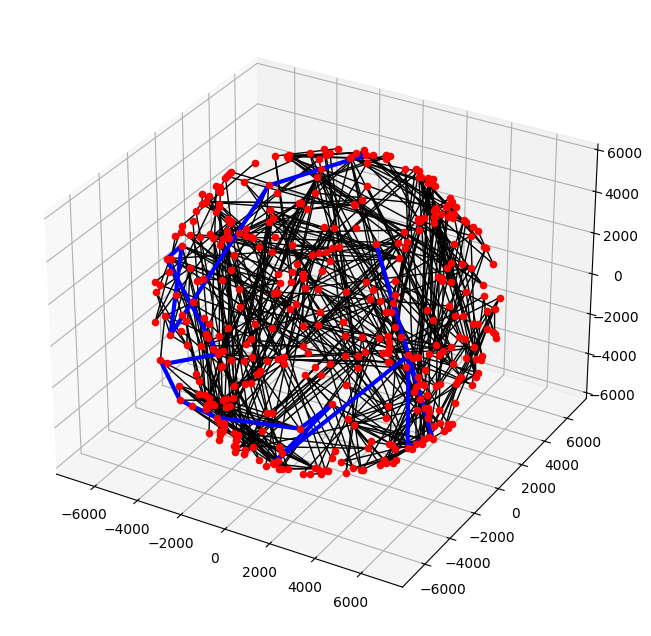

In [198]:
draw_route(G,route)

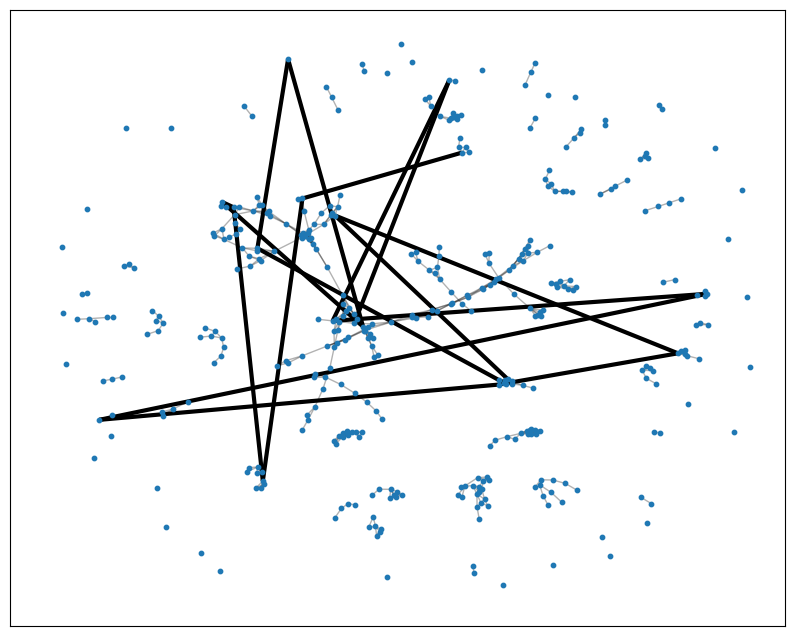

In [199]:
draw_route2(G,route)